# TARDIS Spectral Simulation for Supernovae

This notebook:
1. Loads an observed supernova spectrum (from WISeREP, processed by the pipeline)
2. Builds a TARDIS configuration based on the SN type and DASH classification
3. Runs the TARDIS radiative transfer simulation
4. Compares the simulated spectrum with observations

**Prerequisites:**
- `tardis` conda environment with TARDIS installed
- Atomic data file `kurucz_cd23_chianti_H_He_latest.h5` in `data/`
- Observed spectrum `.dat` file in `output/{target}/spectrum/`


In [13]:
# =============================================
#  Imports & Setup
# =============================================

import numpy as np
import matplotlib.pyplot as plt
import yaml
import os
import sys
from pathlib import Path

# Allow imports from project root
PROJECT_ROOT = Path(os.path.abspath('..'))
sys.path.insert(0, str(PROJECT_ROOT))

# TARDIS
from tardis import run_tardis
from tardis.io.configuration.config_internal import get_data_dir

# Astropy helpers
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

# Suppress excessive warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 11,
})

print("All imports ready")
print(f"  Python: {sys.version.split()[0]}")
print(f"  Project root: {PROJECT_ROOT.resolve()}")


All imports ready
  Python: 3.13.3
  Project root: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline


## 1. Load Observed Spectrum

Select the target and load the WISeREP spectrum `.dat` file produced by the pipeline.


Target: SN2026jlm
Spectrum: spectrum_90904.dat
   Wavelength: 3776.7 - 9223.3 A,  N=214


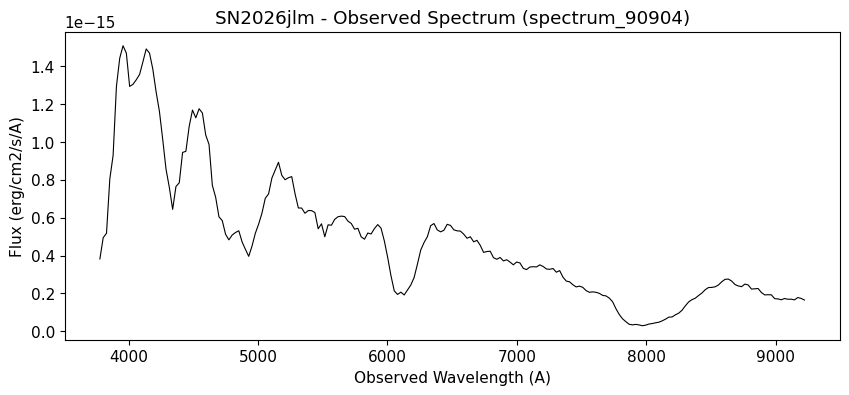

In [14]:
# =============================================
#  1. Load Observed Spectrum
# =============================================

TARGET = "SN2026jlm"            # <--- change target here
SPECTRUM_DIR = PROJECT_ROOT / f"output/{TARGET}/spectrum"
SPECTRUM_FILES = sorted(SPECTRUM_DIR.glob("spectrum_*.dat"))

if not SPECTRUM_FILES:
    raise FileNotFoundError(f"No spectrum .dat files in {SPECTRUM_DIR.resolve()}")

spec_file = SPECTRUM_FILES[0]
print(f"Target: {TARGET}")
print(f"Spectrum: {spec_file.name}")

data = np.loadtxt(spec_file, comments="#")
wave_obs = data[:, 0]        # Observed wavelength (Angstrom)
flux_obs = data[:, 1]        # Flux (erg/cm^2/s/A)

print(f"   Wavelength: {wave_obs[0]:.1f} - {wave_obs[-1]:.1f} A,  N={len(wave_obs)}")

# Quick plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wave_obs, flux_obs, 'k-', lw=0.8)
ax.set_xlabel("Observed Wavelength (A)")
ax.set_ylabel("Flux (erg/cm2/s/A)")
ax.set_title(f"{TARGET} - Observed Spectrum ({spec_file.stem})")
plt.show()


## 2. Target Parameters

Set the supernova parameters. These should come from:
- **Redshift** (`z`): from TNS catalog / WISeREP
- **Type**: from DASH classification (`Ia-norm`, `II-norm`, etc.)
- **Epoch** (`time_explosion`): days since explosion
  - For Ia: peak at ~18 days, so if DASH says *+1 day from peak*, epoch ~19 days
- **Luminosity** (`luminosity_requested`): estimated from apparent magnitude + distance
- **Velocity range**: from DASH expansion velocity measurement (photosphere ~70% of v_exp)


In [15]:
# =============================================
#  2. Target Parameters  (EDIT ME)
# =============================================

# --- From pipeline / DASH classification ---
target_z   = 0.0167              # Redshift
sn_type    = "Ia"                # "Ia", "II", "Ibc"
dash_age   = 1.0                 # Days relative to peak (from DASH)
dash_vel   = 15653               # Expansion velocity km/s (from absorption min)

# Ia epoch estimate: peak at ~18 days after explosion
if sn_type == "Ia":
    epoch_days = dash_age + 18.0
else:
    epoch_days = dash_age + 15.0   # approximate for II

# --- Luminosity estimate (from apparent mag + redshift) ---
apparent_mag = 16.0               # Apparent magnitude at spectrum epoch
d_L = cosmo.luminosity_distance(target_z).to(u.pc).value  # pc
dist_modulus = 5 * np.log10(d_L / 10)
abs_mag = apparent_mag - dist_modulus
lum_sol = 10 ** (0.4 * (4.74 - abs_mag))   # bolometric mag sun = 4.74
lum_log_sol = np.log10(lum_sol)
print(f"   Distance:   {d_L/1e6:.1f} Mpc")
print(f"   Dist mod:   {dist_modulus:.1f}")
print(f"   Abs. mag:   {abs_mag:.1f}")
print(f"   Luminosity:  {lum_sol:.2e} L_sun  =  {lum_log_sol:.2f} log(Lsun)")

# --- Velocity range for TARDIS ---
# TARDIS needs inner/outer boundary velocities. Photosphere is ~0.7 * v_exp for Ia
v_phot = dash_vel * 0.7
v_start = v_phot * 0.7              # Inner boundary (~60% photosphere)
v_stop  = dash_vel * 1.3            # Outer boundary
print(f"   Velocity:    phot={v_phot:.0f}  range=[{v_start:.0f}, {v_stop:.0f}] km/s")
print(f"   Epoch:       {epoch_days:.0f} days since explosion")


   Distance:   74.9 Mpc
   Dist mod:   34.4
   Abs. mag:   -18.4
   Luminosity:  1.76e+09 L_sun  =  9.25 log(Lsun)
   Velocity:    phot=10957  range=[7670, 20349] km/s
   Epoch:       19 days since explosion


## 3. Build TARDIS Configuration

Generate a YAML configuration from the template and target parameters.
The config is written to `configs/tardis/{target}.yml`.


In [16]:
# =============================================
#  3. Build TARDIS Config
# =============================================

# Load base template
base_config_path = PROJECT_ROOT / "configs/tardis/base_Ia.yml"
with open(base_config_path) as f:
    config = yaml.safe_load(f)

# Override with target-specific values
config["supernova"]["luminosity_requested"] = f"{lum_log_sol:.2f} log_lsun"
config["supernova"]["time_explosion"]       = f"{epoch_days:.1f} day"
config["model"]["structure"]["velocity"]["start"] = f"{v_start:.1f} km/s"
config["model"]["structure"]["velocity"]["stop"]  = f"{v_stop:.1f} km/s"

# atom_data: use absolute path to project data dir
ATOM_H5_PATH = str(PROJECT_ROOT / "data/kurucz_cd23_chianti_H_He_latest.h5")
config["atom_data"] = ATOM_H5_PATH

# For non-Ia types, adjust abundances
if sn_type == "II":
    config["model"]["abundances"] = {
        "type": "uniform",
        "H": 0.70, "He": 0.28,
        "O": 0.01, "Si": 0.005, "S": 0.005,
    }
elif sn_type == "Ibc":
    config["model"]["abundances"] = {
        "type": "uniform",
        "He": 0.50, "O": 0.30, "C": 0.15,
        "Si": 0.03, "S": 0.02,
    }

# Write config
out_config_path = PROJECT_ROOT / f"configs/tardis/{TARGET}.yml"
out_config_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_config_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"Config written to {out_config_path.resolve()}")
print()
print("--- Config preview ---")
with open(out_config_path) as f:
    print(f.read())


Config written to /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/configs/tardis/SN2026jlm.yml

--- Config preview ---
tardis_config_version: v1.0
supernova:
  luminosity_requested: 9.25 log_lsun
  time_explosion: 19.0 day
atom_data: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/data/kurucz_cd23_chianti_H_He_latest.h5
model:
  structure:
    type: specific
    velocity:
      start: 7670.0 km/s
      stop: 20348.9 km/s
      num: 20
    density:
      type: branch85_w7
  abundances:
    type: uniform
    O: 0.19
    Mg: 0.03
    Si: 0.52
    S: 0.19
    Ar: 0.04
    Ca: 0.03
plasma:
  ionization: lte
  excitation: lte
  radiative_rates_type: dilute-blackbody
  line_interaction_type: macroatom
montecarlo:
  seed: 23111963
  no_of_packets: 5.0e4
  iterations: 10
  last_no_of_packets: 1.0e5
  no_of_virtual_packets: 3
  convergence_strategy:
    type: damped
    damping_constant: 0.5
    threshold: 0.05
    lock_t_inner_cycles: 1
    t_inner_update_exponent: -0.5
sp

## 4. Check Atomic Data

TARDIS needs the `kurucz_cd23_chianti_H_He_latest.h5` atomic data file (~212 MB) in the project `data/` directory.

If missing, run the download script:
```bash
conda activate tardis
python scripts/download_tardis_atom_data.py
```


In [17]:
# =============================================
#  4. Check Atomic Data
# =============================================

ATOM_DATA_FILE = Path(ATOM_H5_PATH)
print(f"Looking for: {ATOM_DATA_FILE}")

if ATOM_DATA_FILE.exists():
    size_mb = os.path.getsize(ATOM_DATA_FILE) / 1e6
    print(f"Atomic data found ({size_mb:.0f} MB)")
else:
    print("Atomic data NOT found.")
    print()
    print("Run in terminal:")
    print("  conda activate tardis")
    print("  python scripts/download_tardis_atom_data.py")


Looking for: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/data/kurucz_cd23_chianti_H_He_latest.h5
Atomic data found (212 MB)


## 5. Run TARDIS Simulation

This runs the Monte Carlo radiative transfer simulation.
Duration: ~1-5 minutes depending on packet count and iterations.


In [18]:
# =============================================
#  5. Run TARDIS
# =============================================

if not ATOM_DATA_FILE.exists():
    raise RuntimeError(
        "Atomic data file not found. Please download it first.\n"
        f"Expected: {ATOM_DATA_FILE}\n"
        "See instructions in Cell 4 above."
    )

print(f"Running TARDIS with config: {out_config_path.name}")
print("This may take a few minutes...")
print()

# Run simulation
sim = run_tardis(
    str(out_config_path),
    show_convergence_plots=False,
    log_level="WARNING",
)

print()
print("Simulation complete!")
print(f"  Iterations executed: {sim.iterations_executed}")
print(f"  Inner temperature:   {sim.simulation_state.t_inner:.1f}")
print(f"  Luminosity requested:{sim.luminosity_requested}")
print()

# Extract spectrum
spectrum = sim.spectrum_solver.spectrum_real_packets
print(f"  Spectrum: {len(spectrum.wavelength)} points, "
      f"{spectrum.wavelength[0]:.0f} - {spectrum.wavelength[-1]:.0f} A")


Running TARDIS with config: SN2026jlm.yml
This may take a few minutes...



Embedding the final state for Jupyter environments

Simulation complete!
  Iterations executed: 10
  Inner temperature:   10889.7 K
  Luminosity requested:6.839262611009648e+42 erg / s

  Spectrum: 10000 points, 20000 Angstrom - 500 Angstrom A


## 6. Compare Simulated vs Observed

De-redshift the observed spectrum to the rest frame and overlay with the TARDIS simulated spectrum.


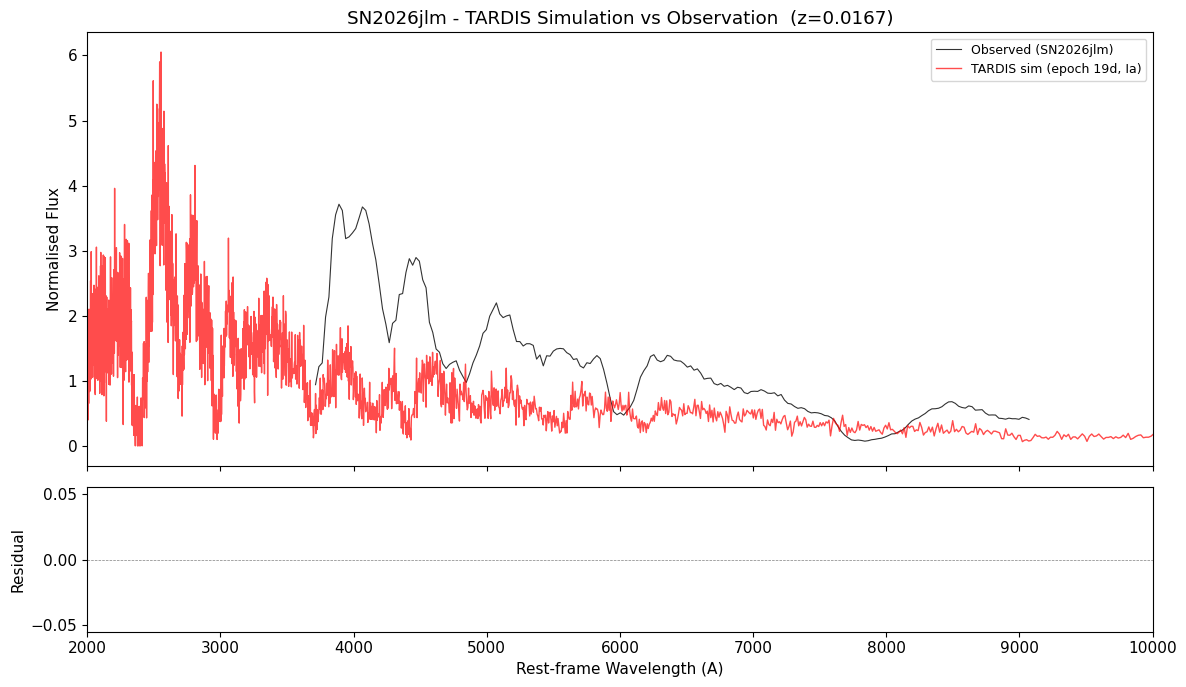

In [19]:
# =============================================
#  6. Compare Spectra
# =============================================

# Rest-frame correction for observed
wave_rest = wave_obs / (1 + target_z)
# Normalise both to similar scale
flux_obs_norm = flux_obs / np.median(flux_obs)

# TARDIS spectrum
tardis_wave = spectrum.wavelength.value   # Already in rest frame (Angstrom)
tardis_flux = spectrum.luminosity_density_lambda.value
tardis_flux_norm = tardis_flux / np.median(tardis_flux[tardis_flux > 0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Top panel: spectra
ax1.plot(wave_rest, flux_obs_norm, 'k-', lw=0.8, alpha=0.8,
         label=f'Observed ({TARGET})')
ax1.plot(tardis_wave, tardis_flux_norm, 'r-', lw=1.0, alpha=0.7,
         label=f'TARDIS sim (epoch {epoch_days:.0f}d, {sn_type})')
ax1.set_ylabel("Normalised Flux")
ax1.legend(fontsize=9, loc='upper right')
ax1.set_title(f"{TARGET} - TARDIS Simulation vs Observation  (z={target_z})")

# Bottom panel: residual (only where wavelengths overlap)
t_flux_interp = np.interp(wave_rest, tardis_wave, tardis_flux_norm,
                          left=np.nan, right=np.nan)
residual = flux_obs_norm - t_flux_interp
valid = np.isfinite(residual)
ax2.plot(wave_rest[valid], residual[valid], 'b-', lw=0.6, alpha=0.7)
ax2.axhline(0, color='gray', ls='--', lw=0.5)
ax2.set_xlabel("Rest-frame Wavelength (A)")
ax2.set_ylabel("Residual")
ax2.set_xlim(2000, 10000)

plt.tight_layout()
plt.show()


## 7. Save Simulation Results

Export the TARDIS spectrum for further analysis.


In [20]:
# =============================================
#  7. Save Results
# =============================================

import shutil

out_dir = PROJECT_ROOT / f"output/{TARGET}/tardis"
out_dir.mkdir(parents=True, exist_ok=True)

# Save TARDIS spectrum as ASCII (2-column)
spec_out = np.column_stack([tardis_wave, tardis_flux])
np.savetxt(out_dir / f"tardis_spectrum_{TARGET}.dat", spec_out,
           header="wavelength(A)  flux(erg/cm2/s/A)")

# Save the config used
shutil.copy(out_config_path, out_dir / f"tardis_config_{TARGET}.yml")

print(f"Results saved to {out_dir.resolve()}/")
print(f"  tardis_spectrum_{TARGET}.dat")
print(f"  tardis_config_{TARGET}.yml")


Results saved to /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/output/SN2026jlm/tardis/
  tardis_spectrum_SN2026jlm.dat
  tardis_config_SN2026jlm.yml


## Next Steps

- **Tune parameters**: Adjust `luminosity_requested`, `time_explosion`, velocity range, and abundances
- **Try other targets**: Change `TARGET` (e.g., `SN2026fov`, `SN2026kid`) and re-run
- **Explore density profiles**: Switch from `branch85_w7` to `exponential` or `power_law`
- **Change plasma physics**: Try `ionization: nebular`, `excitation: dilute-lte`, `line_interaction_type: scatter`
- **Run grid**: Loop over luminosity/epoch combinations to find best fit
- **Compare with DASH**: Cross-validate the DASH classification with TARDIS model fit
